In [13]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv, MIRS_gurobi_env
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 
import time
import math
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

n_waypoints: 3 
n_agents: 2 
CAT:
[5. 5. 5.]
---------
wp_locations:
[[  69.76353945  -64.22081502]
 [4910.87264286  -27.69231078]
 [ -44.91981428 5006.00004498]] 
mask:
[[0 1 1]
 [1 0 0]
 [1 0 0]] 
dist_mat:
[[1.00000000e+08 4.84124691e+03 5.07151771e+03]
 [4.84124691e+03 1.00000000e+08 1.00000000e+08]
 [5.07151771e+03 1.00000000e+08 1.00000000e+08]] 
wp_weights:
[0.33333333 0.33333333 0.33333333]
---------
agent_weights:
[0.5 0.5] 
sd_mat:
[[2 1]
 [2 1]] 
eta_arr: 
processing_time:
[[0. 0. 0.]
 [0. 0. 0.]] 
speed_lim_mat:
[[6.38195822e-02 7.27540093e+01]
 [3.67923062e-01 7.53000022e+01]] 
sched_mat:
[[15.29594579 15.22371796  0.        ]
 [12.49495069 45.88149489  0.        ]] 
speed_vec:
[36.40891443 37.83396266]


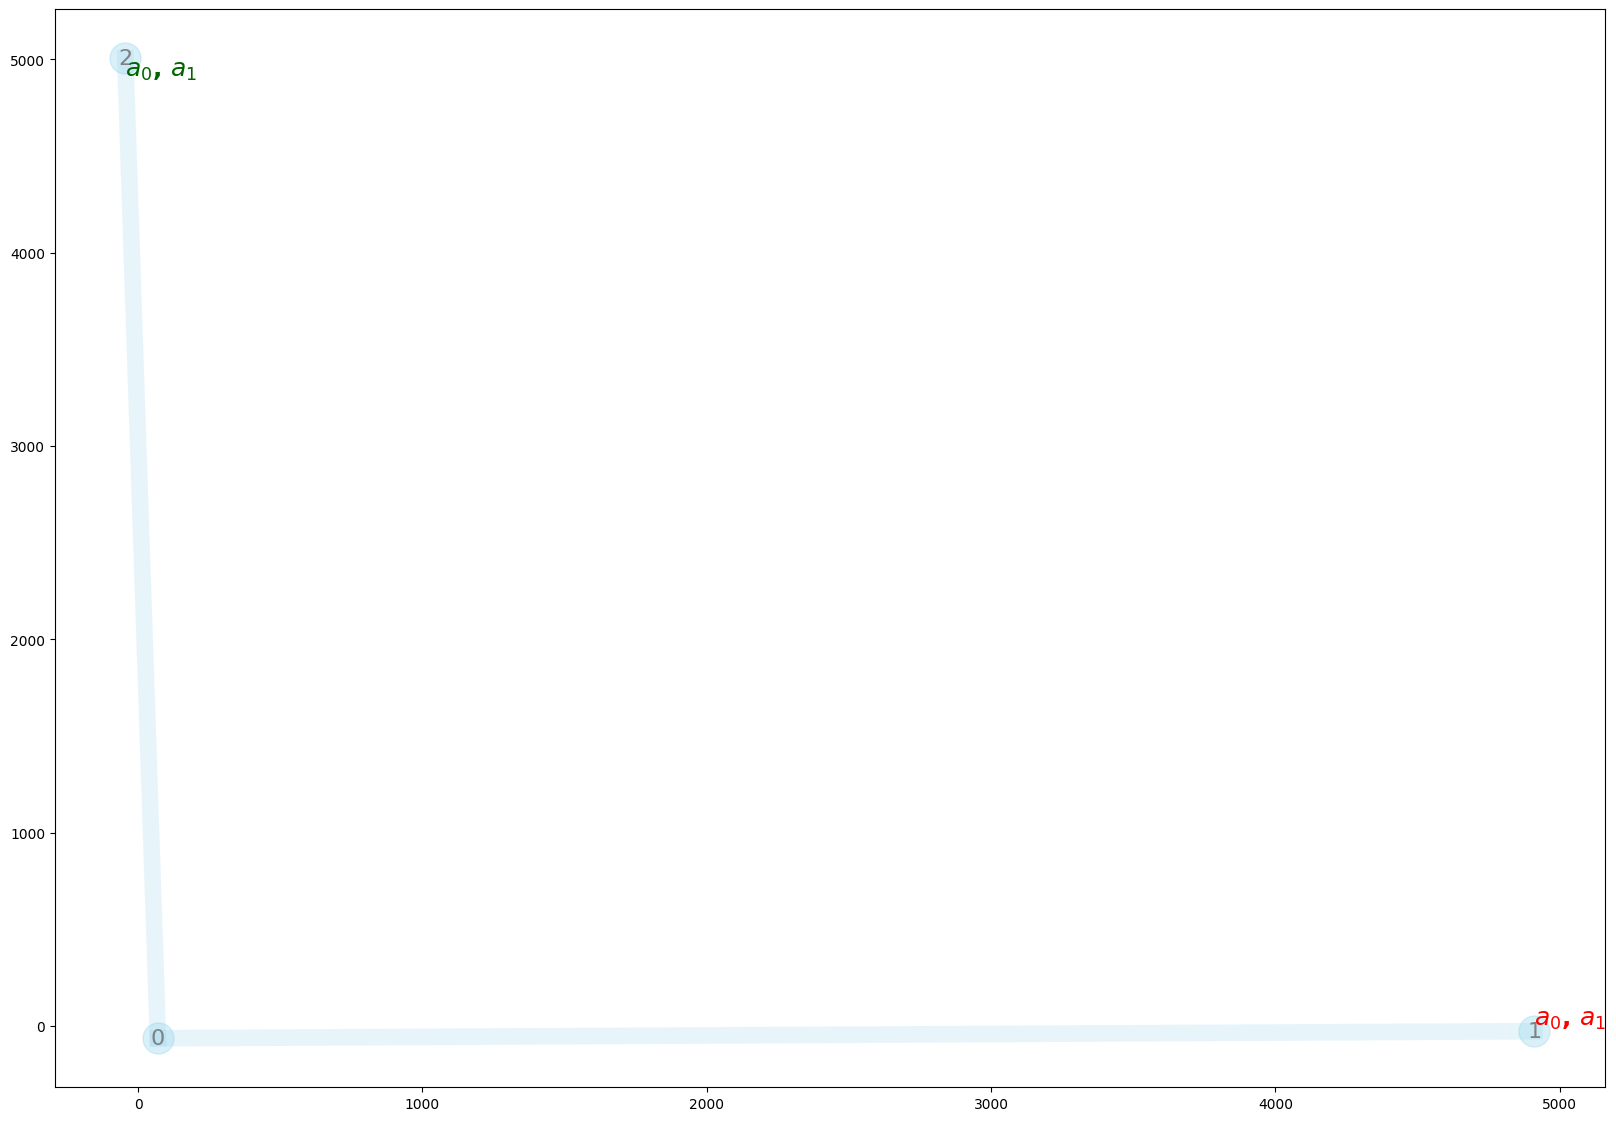

In [14]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 3
n_agents = 2
tolArray = np.random.uniform(5.0, 5.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':5000,
    'noise_factor':100,
    'extra_connections':0
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.3,
    'missing_connections':0.05
}

multigraph_params = {
    'type':'multigraph',
    'n_points':n_waypoints,
    'n_graphs':4,
    'grid_size':10000.0,
    'intra_graph_connectivity':0.2,
    'inter_graph_connectivity':0.01,
    'subgraph_type':'grid',
    'seed':None
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# rectangular cbf mode
ca_cbf_rect = {
    'mode':'rect',
    'width':1e-3*tolArray,
    'height':1e-4*tolArray,
    'gamma':1,
    'width_correction_fac':0.5,
    'height_correction_fac':0.5
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params,
    seed=15,
    offset_energy=1,
    stagewiseCostCoeffs=np.array([1, 100.0, 1.0]),
    selfHop=0,
    ca_cbf=ca_cbf_rect,
    cost_mode=cost_mode,
    lm = lm,
    filter_wp_thresh=1e-10,
    prune_mode=False,
    printFlag=True)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(20,14), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# Prepare to save
dir_name = '/Users/dhananjaytiwari/Documents/NASA_ULI/MIRS_Journal/MIRS_Results'
scene_name = multigraph_params['type'] + f'Nw{n_waypoints}_Na{n_agents}'

In [15]:

gurobi_distMat = cdist(mars.wp_locations, mars.wp_locations, 'euclidean')
min_inv_speed = 1/np.max(mars.speed_lim_mat) 
max_inv_speed = 1/np.min(mars.speed_lim_mat) 


In [16]:

# initialize stage sizes 
stage_sizes = [] 
K = mars.n_waypoints+1 
for k in range(K+1):
    if k == 0 or k == K:
        stage_sizes.append(1)
    else:
        stage_sizes.append(mars.n_waypoints)
print(f"stage_sizes:{stage_sizes}")
print(f"inverse speed range: ({min_inv_speed:.3e},\t{max_inv_speed:.3e})")


stage_sizes:[1, 3, 3, 3, 1]
inverse speed range: (1.328e-02,	1.567e+01)


In [17]:
mars.sd_mat

array([[2, 1],
       [2, 1]])

In [18]:

mirs_gb = MIRS_gurobi_env.MIRS_Gurobi(
        num_agents = mars.n_agents,
        num_waypoints = mars.n_waypoints,
        start_goal = mars.sd_mat,
        theta_bounds = (0, mars.T_upper_bound),
        inv_speed_bounds = (min_inv_speed, max_inv_speed),
        INF = mars.INF,
        stage_sizes = stage_sizes,
        mask = mars.mask,
        start_times = mars.start_times,
        distMat = gurobi_distMat,
        tolerance = mars.tolArray,
        stagewiseCostCoeffs = mars.stagewiseCostCoeffs
)




Set parameter NonConvex to value 2


In [19]:
mirs_gb.optimize()

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.05
Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.8
Set parameter Cuts to value 2
Set parameter OBBT to value 2
Set parameter NumericFocus to value 2
Set parameter Presolve to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.05
Heuristics  0.8
MIPFocus  1
OBBT  2
Cuts  2
NonConvex  2
NumericFocus  2
Presolve  2

Optimize a model with 60 rows, 152 columns and 86 nonzeros
Model fingerprint: 0xf58ccff1
Model has 73 quadratic constraints
Variable types: 104 continuous, 48 integer (48 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 3e+09]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 9e+00]
  Bounds range     [1e-02, 6e

In [21]:
mirs_gb.print_solution()


=== SOLUTION SUMMARY ===

--- Distance matrix ---
[[   0.         4841.24691404 5071.51770585]
 [4841.24691404    0.         7063.84722447]
 [5071.51770585 7063.84722447    0.        ]]

Agent: 0

--- Start / Goal ---
Start: 2	Theta: 0.000
Goal : 1	Theta: 131.644

--- Theta values ---
theta[0,0] = 67.350828
theta[0,1] = 131.643613
theta[0,2] = 0.000000

--- Inverse Speed ---
inv_speed[0] = 0.013280

--- Stagewise variables ---

  Stage 0 -> 1
Z[0,0,0,0] = 4.536e+03, eta[0,0,0,0] = 1, Xi[0,0,0,0] = 4.536e+03
Z[0,0,0,1] = 0.000e+00, eta[0,0,0,1] = 0, Xi[0,0,0,1] = 1.000e+08
Z[0,0,0,2] = 0.000e+00, eta[0,0,0,2] = 0, Xi[0,0,0,2] = 1.000e+08

  Stage 1 -> 2
Z[0,1,0,0] = 0.000e+00, eta[0,1,0,0] = 0, Xi[0,1,0,0] = 1.000e+08
Z[0,1,0,1] = 4.134e+03, eta[0,1,0,1] = 1, Xi[0,1,0,1] = 4.134e+03
Z[0,1,0,2] = 0.000e+00, eta[0,1,0,2] = 0, Xi[0,1,0,2] = 1.819e+06
Z[0,1,1,0] = 0.000e+00, eta[0,1,1,0] = 0, Xi[0,1,1,0] = 1.000e+08
Z[0,1,1,1] = 0.000e+00, eta[0,1,1,1] = 0, Xi[0,1,1,1] = 0.000e+00
Z[0,1,1,